# Cifar-10 FCN

In [33]:
import keras
from keras import layers

import tensorflow as tf
from tensorflow.keras.datasets import cifar10

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
import seaborn as sns

import warnings

warnings.filterwarnings(
    "ignore",
    message=".*align should be passed as Python or NumPy boolean.*"
)

## Data Preparation and understanding

The CIFAR‑10 dataset is loaded into memory, after which the class_names and num_classes variables are initialized to provide human‑readable labels for the feature variables.

In [34]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

num_classes = 10

Preprocessing of the dataset begins with normalizing the feature variables, as constraining values to the range 0–1 typically reduces volatility and stabilizes model training. After normalization, the target variables are one‑hot encoded to ensure that the model interprets each class as a distinct, non‑ordinal category.

In [3]:
x_train, x_test = x_train / 255.0, x_test / 255.0

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

Below are ten sample images from the dataset with their corresponding labels. Due to the low resolution of 32×32 pixels, the images appear noticeably blocky, which can make visual recognition sometimes challenging even for human eyes.

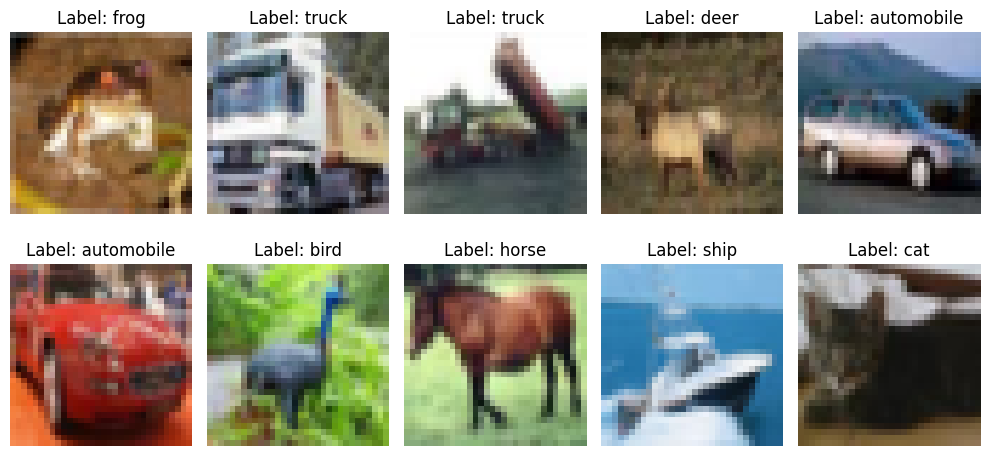

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_train[i])
    ax.set_title(f'Label: {class_names[np.argmax(y_train[i])]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

The shapes and sizes of the feature and target variables are printed to verify that the data has been loaded correctly and to determine the appropriate input dimensions for the model.

In [5]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

x_train shape: (50000, 32, 32, 3)
x_test shape: (10000, 32, 32, 3)
50000 train samples
10000 test samples


In [6]:
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (50000, 10)
y_test shape: (10000, 10)


## Modeling

### Final model

A simple Fully Convolutional Network (FCN) is constructed to perform the image‑recognition task.

Before entering the dense layers, the input image is flattened from its original 32×32×3 tensor representation into a single vector of length 3,072. This is a required step, as dense layers cannot operate directly on multidimensional data and instead expect a one‑dimensional input vector.

The model includes three dense hidden layers with progressively decreasing numbers of neurons to encourage feature abstraction. Each dense layer uses the ReLU activation function, and dropout layers are inserted after every hidden layer to mitigate overfitting, as the model was found to be quite prone to it.

Finally, the output layer condenses the learned representation into a ten‑dimensional vector, corresponding to the ten dataset classes, and applies a softmax activation function to produce a normalized probability distribution over all possible labels.

The final model has nearly four million trainable parameters. The summary of the model can be found below.

In [7]:
input_shape = (32, 32, 3)

inputs = keras.Input(shape=input_shape)
x = layers.Flatten()(inputs)

x = layers.Dense(1024, activation="relu")(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

The model is then compiled using the Adam optimizer, with the learning rate adjusted to 0.0001 to promote stable learning as larger values were found to be more volatile. The loss function is set to categorical crossentropy, which fits the multi‑class classification tasks in hand.

In [8]:
optimizer = keras.optimizers.Adam(learning_rate=0.0001)
loss = keras.losses.CategoricalCrossentropy()

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy"]
)

A batch size of 128 was ultimately selected, as it was found to produce a stable and consistent learning curve during experimentation. Through testing, 50 epochs were identified as the optimal training duration, providing a balance between sufficient learning and avoiding overfitting. Additionally, 20% of the training data is reserved validation.

In [9]:
history = model.fit(x_train, y_train, batch_size=128, epochs=50, validation_split=0.2)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.2251 - loss: 2.0856 - val_accuracy: 0.3232 - val_loss: 1.8910
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.3091 - loss: 1.9004 - val_accuracy: 0.3653 - val_loss: 1.7914
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.3410 - loss: 1.8219 - val_accuracy: 0.3802 - val_loss: 1.7389
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.3656 - loss: 1.7638 - val_accuracy: 0.3999 - val_loss: 1.6946
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.3876 - loss: 1.7137 - val_accuracy: 0.4164 - val_loss: 1.6388
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4020 - loss: 1.6746 - val_accuracy: 0.4290 - val_loss: 1.6041
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4173 - loss: 1.6411 - val_accuracy: 0.4327 - val_loss: 1.5992
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4284 - loss: 1.6079 - val_acc

### Tested improvements

#### Structure
Different layer configurations were also tested, including models with fewer neurons per layer and a deeper model that added an extra layer with 2048 neurons. Through these experiments, the final architecture appeared to strike the best balance between depth and width. It provided enough capacity to learn meaningful patterns without introducing unnecessary complexity or overfitting, effectively hitting a “sweet spot”. The siphon‑like layer structure also appeared to perform better than architectures with a constant number of neurons per layer. Gradually reducing the layer width helps the network compress information in a controlled way, encouraging it to learn increasingly abstract representations rather than forcing all layers to process features at the same level of complexity.

#### Regularization
Both L2 regularization and batch normalization were tested as potential regularization methods. They were evaluated individually, in combination with each other, and together with the chosen dropout strategy. In the end, dropout proved to provide the most substantial improvement, while the additional gains from combining it with L2 regularization or batch normalization were negligible. To keep the model simple and avoid unnecessary complexity, dropout was selected as the primary regularization method. Different dropout percentages were also tested, and while the overall impact on accuracy was modest, using 20% dropout in the earlier layers and 30% in the final layer provided a small but consistent improvement. This configuration gave the final model roughly a 0.5% performance edge compared to the other tested dropout settings.

#### Data augmentation
Data augmentation was also tested, but it was quickly discarded because it made the already low‑resolution images even noisier. Since CIFAR‑10 images are only 32×32 pixels, transformations such as rotations, shifts, or zooming tended to distort important features rather than improve generalization, ultimately significaltly harming the model performance.

## Evaluation

The loss and accuracy values for both the training and validation sets are recorded at each epoch and plotted to allow for visual assessment of the model’s learning behavior.

As shown in both graphs, the validation curve initially follows the training curve closely, but begins to diverge at around epoch 18. Training is continued until the validation loss starts to increase, indicating the onset of overfitting. At this point, learning is stopped and the model is considered ready for evaluation.

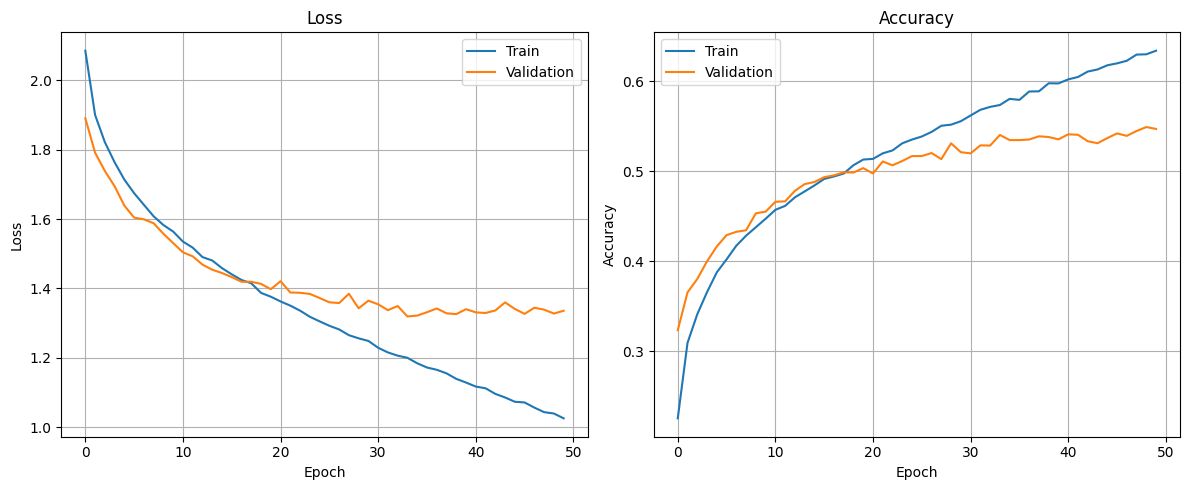

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(history.history["loss"])
ax[0].plot(history.history["val_loss"])
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend(["Train", "Validation"])
ax[0].grid()

ax[1].plot(history.history["accuracy"])
ax[1].plot(history.history["val_accuracy"])
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend(["Train", "Validation"])
ax[1].grid()

plt.tight_layout()
plt.show()

The model is now complete and can be evaluated using the test dataset that was set aside at the beginning. The final accuracy achieved on the test set is 54%, which is a reasonable result for a model of this simplicity, especially given the complexity of the classification task and low‑resolution nature of the dataset images.

In [11]:
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 1s - 4ms/step - accuracy: 0.5431 - loss: 1.3216
Test loss: 1.3216074705123901
Test accuracy: 0.5430999994277954


A confusion matrix is used to identify which classes the model struggles with the most. From the matrix, it becomes clear that the model has particular difficulty distinguishing between cats and dogs, as well as between automobiles and trucks. From a broader perspective, the model appears to distinguish between vehicles and animals relatively well, with most misclassifications occurring within these two superclasses rather than between them.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


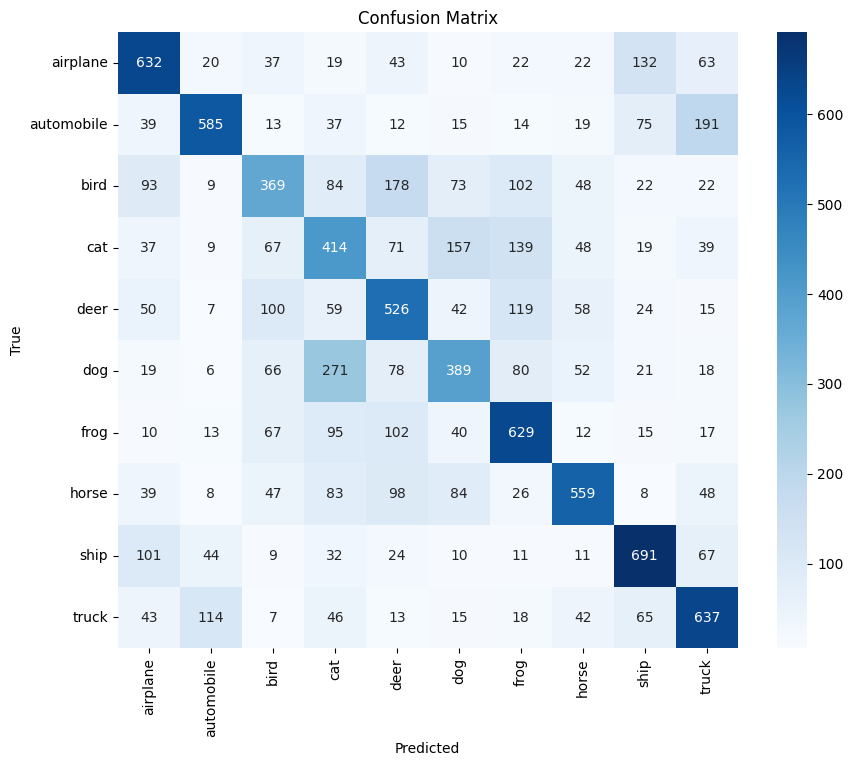

In [12]:
y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Finally a barchart is used to visualize differences in recognition accuracy between the different classes. The chart shows the model shines the most when presented with automobiles and cars, reaching over 65 % accuracy while struggling with recognizing birds managing to reach only little bit higher than 30 % accuracy. When Compared to the 10 % that randomly guessing the class should give, the 30 % accuracy when recognizing cats is quite low and cannot be seen as success.

In [13]:
num_classes = 10
class_acc = []

for c in range(num_classes):
    idx = np.where(y_true_classes == c)[0]
    correct = np.sum(y_pred_classes[idx] == c)
    acc = correct / len(idx)
    class_acc.append(acc)

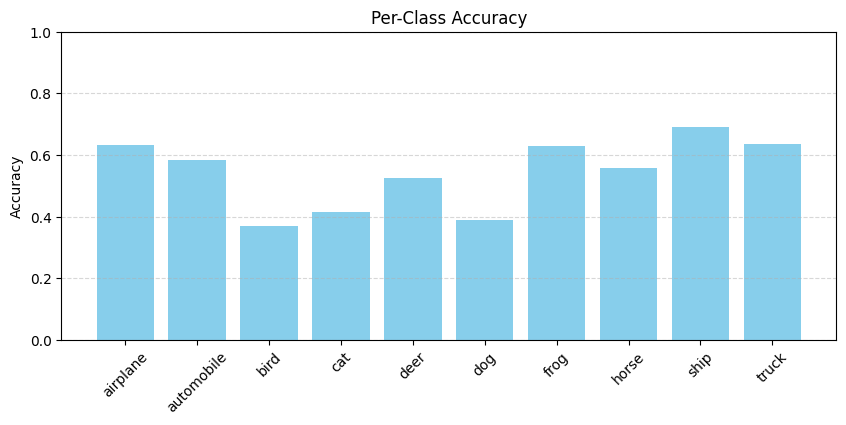

In [14]:
plt.figure(figsize=(10, 4))
plt.bar(class_names, class_acc, color="skyblue")
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

Below are sample images from the test set, each annotated with the true label and the model’s predicted label. As noted earlier, the low resolution of CIFAR‑10 images makes some samples challenging even for human observers. Case in point, the first image of the set of images below. Surprisingly the model is able to predict the label of this image correctly.

In this image set, the model confuses several ships with airplanes. This is a fairly understandable error given the characteristics of CIFAR‑10 images. Both classes often share similar visual cues: many ship images include large areas of sky, and both ships and airplanes tend to have long, streamlined shapes designed to reduce drag. In low‑resolution images like these, those shared features can dominate the model’s attention, making it harder to distinguish between the two categories.

The model also misclassifies one dog as a cat in this set. This is a common type of error, since dogs and cats share many visual similarities in low‑resolution images: similar color palettes and overall body shapes.

As can be seen from the 20 images shown below, the model rarely confuses animals with vehicles. In fact, every misclassification in this sample occurs within these broader superclasses. The model is highly reliable at distinguishing animals from vehicles, but it struggles with finer‑grained differences inside each group.

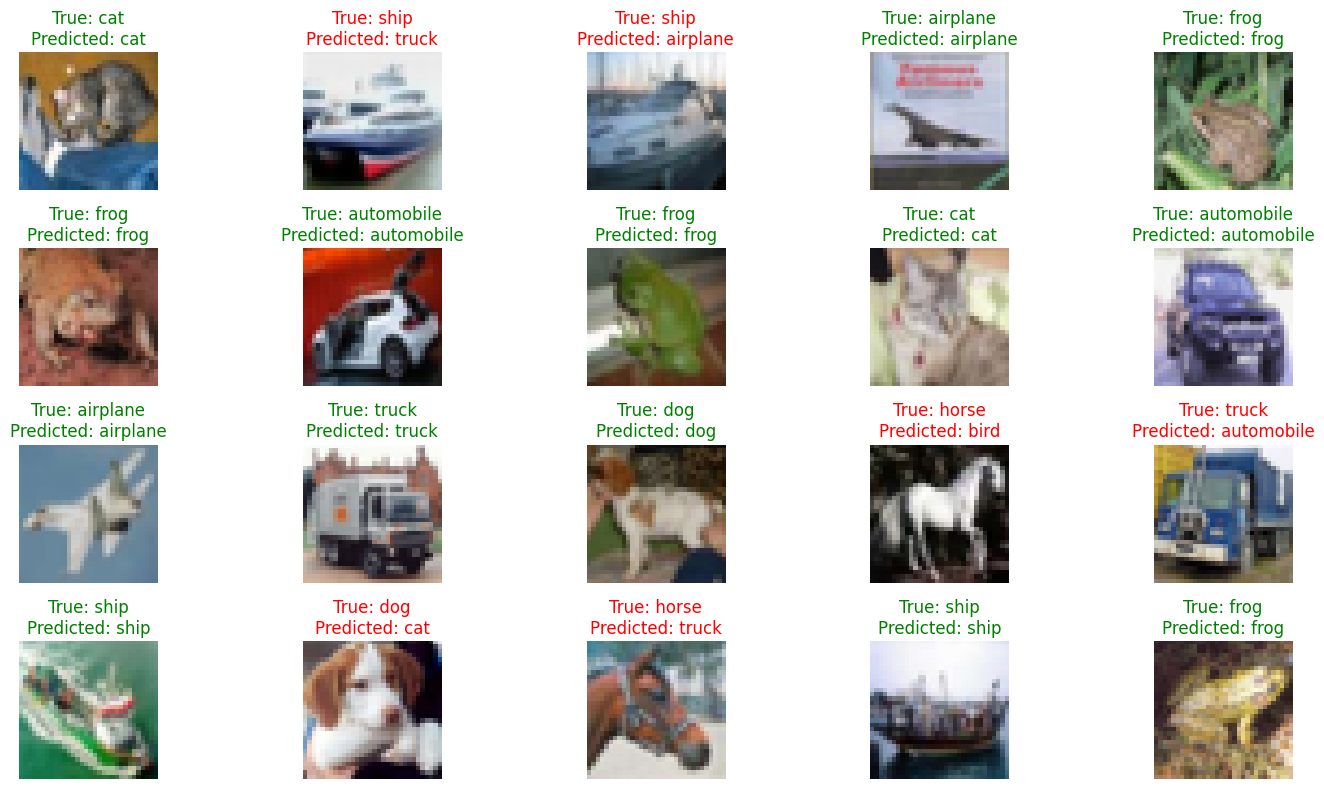

In [25]:
y_test = y_test.astype(int).flatten()

plt.figure(figsize=(15, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[i])
    plt.axis("off")

    color = "green" if y_true_classes[i] == y_pred_classes[i] else "red"
    plt.title(f"True: {class_names[y_true_classes[i]]}\nPredicted: {class_names[y_pred_classes[i]]}", color=color)

plt.tight_layout()
plt.show()

All in all, a simple fully connected neural network is able to classify CIFAR‑10 images to a reasonable degree. However, the overall accuracy leaves substantial room for improvement. If the task were limited to predicting only the two superclasses animal and vehicle the models performance would be significantly higher, as this is a much easier distinction to learn.

It appears that a fully connected neural network does not provide enough complexity for this task. By flattening the images into vectors, the model loses important spatial information. The relative positions of pixels, local patterns, and hierarchical structures that are essential for recognizing objects are lost. As a result, the network sees each image as a long list of numbers rather than as a coherent visual pattern. This makes it much harder to learn features such as edges, textures, or shapes, which are crucial for distinguishing between similar classes in CIFAR‑10.